In [1]:
from pathlib import Path
from warnings import simplefilter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.linear_model import LinearRegression

sns.set_style('whitegrid')

In [2]:
transactions = pd.read_csv('../../Time Series/store-sales-time-series-forecasting/transactions.csv',
                     index_col='date', parse_dates=['date']).drop('store_nbr', axis=1)

transactions.fillna(0)

transactions = transactions.iloc[1:1000]

transactions.head()


,transactions
date,
2013-01-02,2111
2013-01-02,2358
2013-01-02,3487
2013-01-02,1922
2013-01-02,1903


In [3]:
transactions["time"] = np.arange(len(transactions.index))

transactions.head()

,transactions,time
date,,
2013-01-02,2111,0
2013-01-02,2358,1
2013-01-02,3487,2
2013-01-02,1922,3
2013-01-02,1903,4


Text(0.5, 1.0, 'Time plot for transactions')

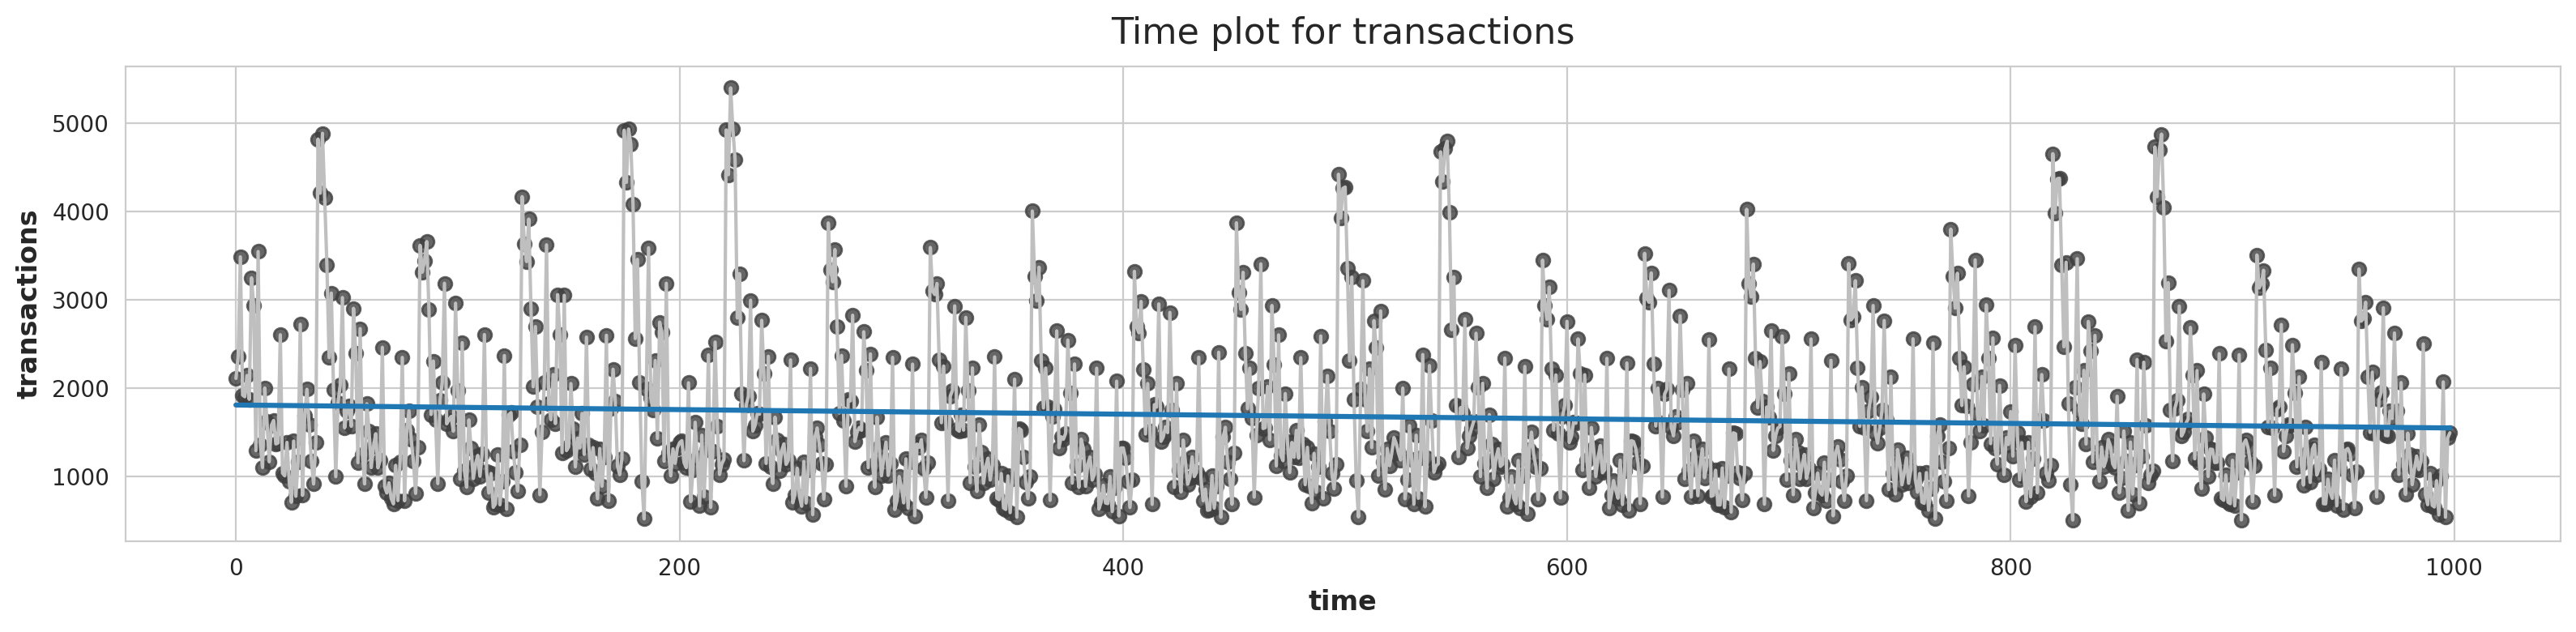

In [4]:
plt.rc(
    "figure",
    autolayout=True,
    figsize=(16, 4),
    titlesize=18,
    titleweight="bold"
)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titlesize=16,
    titlepad=10
)
%config InlineBackend.figure_format = 'retina'

fig, ax = plt.subplots()
ax.plot('time', 'transactions', data=transactions, color='0.75')
ax = sns.regplot(x='time', y='transactions', data=transactions, ci=None, scatter_kws=dict(color='0.25'))
ax.set_title("Time plot for transactions")

In [5]:
transactions['lag_1'] = transactions['transactions'].shift(1)
transactions = transactions.reindex(columns=['transactions', 'lag_1'])

transactions.head()

,transactions,lag_1
date,,
2013-01-02,2111,NaN
2013-01-02,2358,2111.0
2013-01-02,3487,2358.0
2013-01-02,1922,3487.0
2013-01-02,1903,1922.0


In [6]:
type(transactions)

pandas.core.frame.DataFrame

In [7]:
transactions.columns

Index(['transactions', 'lag_1'], dtype='object')

Text(0.5, 1.0, 'Lag plot for transactions')

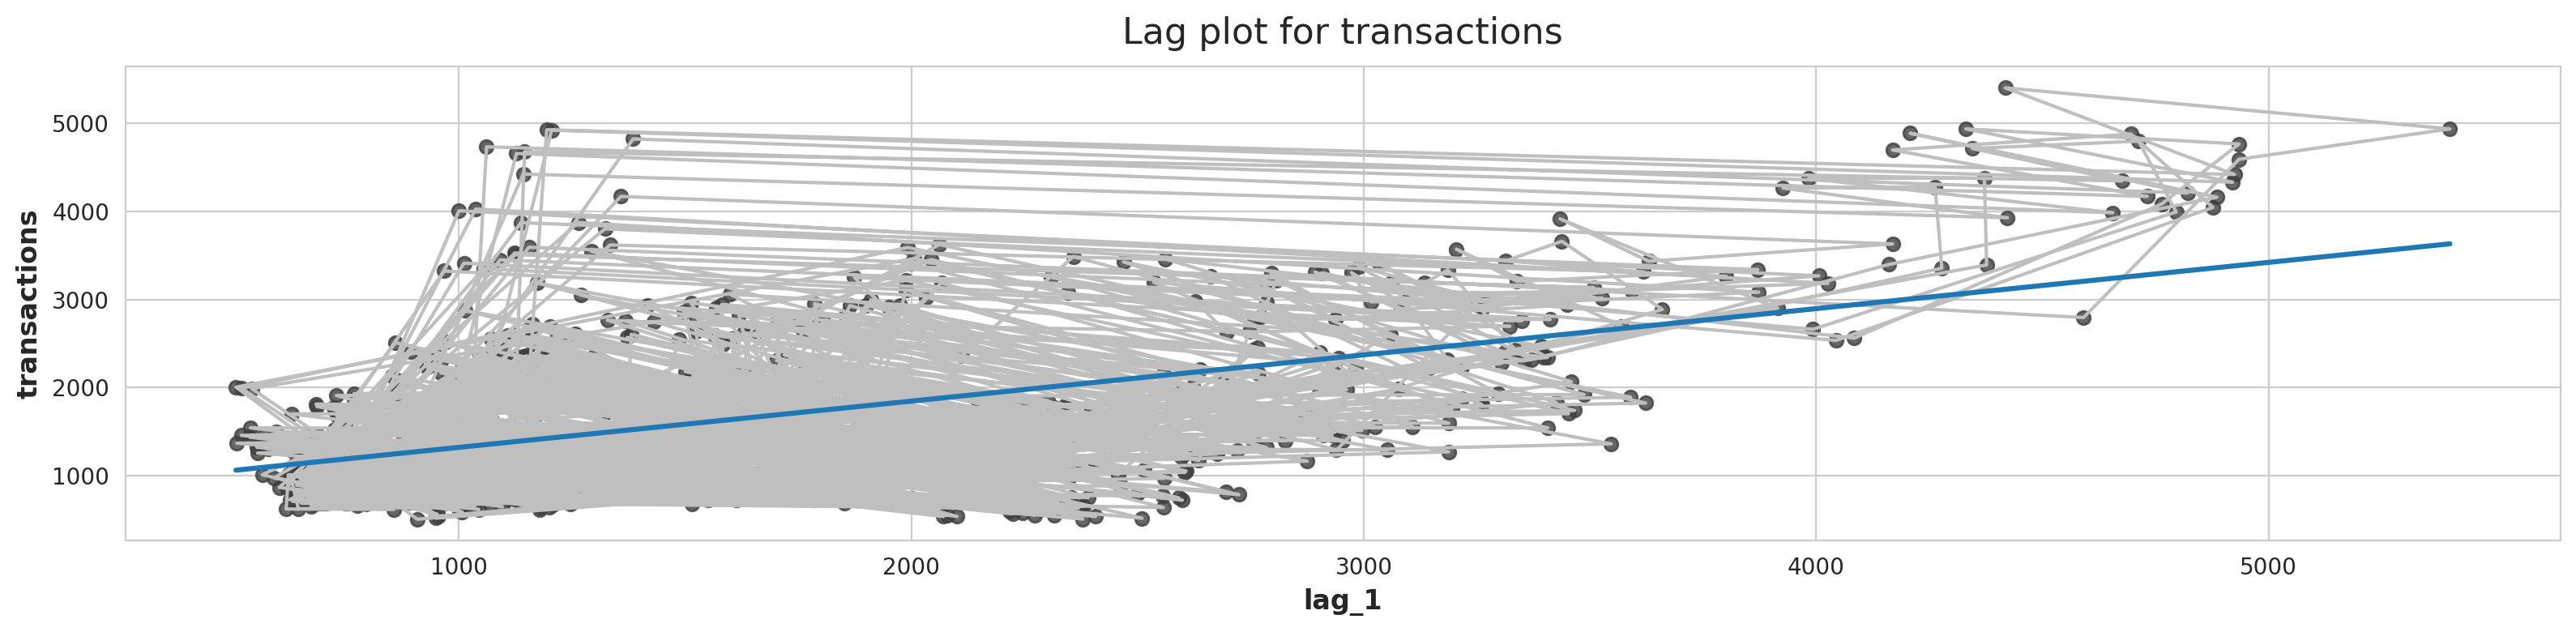

In [8]:
fig, ax = plt.subplots()
ax.plot('lag_1', 'transactions', data=transactions, color='0.75')
ax = sns.regplot(x="lag_1", y="transactions", data=transactions, ci=None, scatter_kws=dict(color='0.25'))
ax.set_title("Lag plot for transactions")

In [56]:
plt.rc("figure", autolayout=True, figsize=(16, 6))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
    legend=False,
)
%config InlineBackend.figure_format = 'retina'

In [10]:
transactions["time"] = np.arange(len(transactions.index))

transactions.head()

,transactions,lag_1,time
date,,,
2013-01-02,2111,NaN,0
2013-01-02,2358,2111.0,1
2013-01-02,3487,2358.0,2
2013-01-02,1922,3487.0,3
2013-01-02,1903,1922.0,4


In [11]:
transactions_copy = transactions.copy().drop("lag_1", axis=1)

transactions_copy.head()

,transactions,time
date,,
2013-01-02,2111,0
2013-01-02,2358,1
2013-01-02,3487,2
2013-01-02,1922,3
2013-01-02,1903,4


In [12]:
X = transactions_copy.loc[:, ['time']]
y = transactions_copy.loc[:, "transactions"]

lm = LinearRegression()
lm.fit(X, y)

y_pred = pd.Series(lm.predict(X), index=X.index)
y_pred

date
2013-01-02    1809.487035
2013-01-02    1809.226409
2013-01-02    1808.965782
2013-01-02    1808.705156
2013-01-02    1808.444529
                 ...     
2013-01-23    1550.424340
2013-01-23    1550.163713
2013-01-23    1549.903087
2013-01-23    1549.642460
2013-01-23    1549.381834
Length: 999, dtype: float64

Text(0.5, 1.0, 'Time plot of transactions')

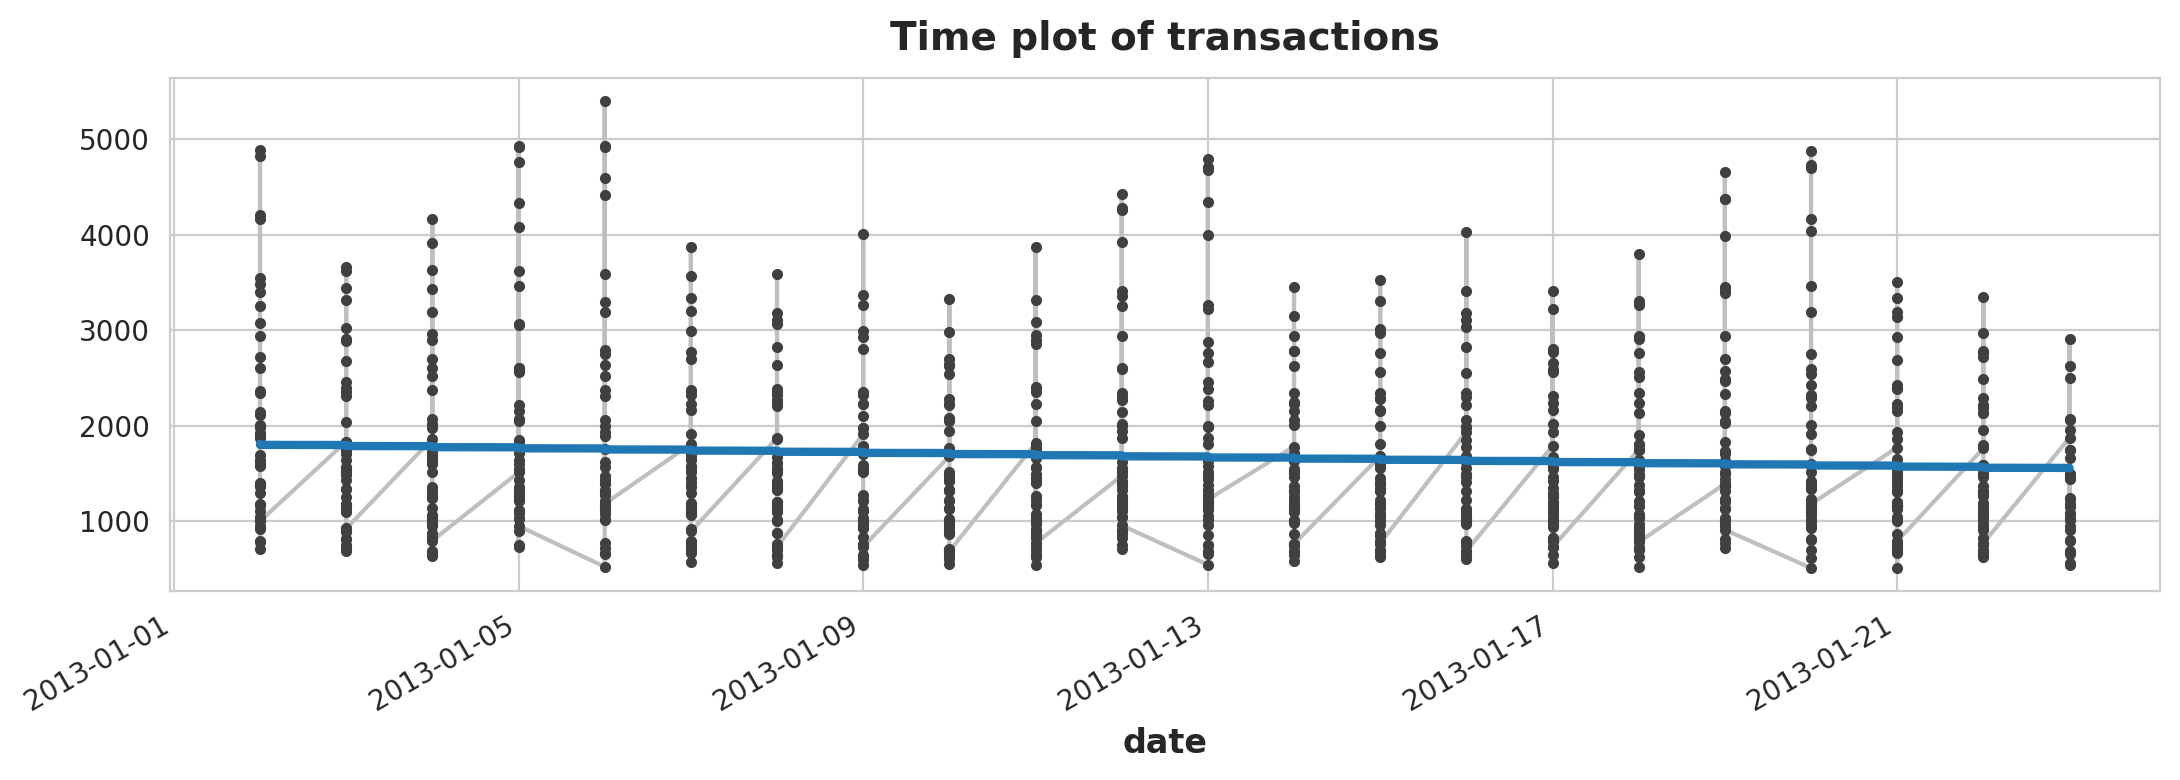

In [13]:
ax = y.plot(**plot_params)
ax = y_pred.plot(ax=ax, linewidth=3)
ax.set_title("Time plot of transactions")

In [14]:
oil = pd.read_csv("../../Time Series/store-sales-time-series-forecasting/oil.csv", index_col="date")

oil.head()

,dcoilwtico
date,
2013-01-01,NaN
2013-01-02,93.14
2013-01-03,92.97
2013-01-04,93.12
2013-01-07,93.20


In [15]:
oil

,dcoilwtico
date,
2013-01-01,NaN
2013-01-02,93.14
2013-01-03,92.97
2013-01-04,93.12
2013-01-07,93.20
...,...
2017-08-25,47.65
2017-08-28,46.40
2017-08-29,46.46


In [16]:
oil.shape

(1218, 1)

In [17]:
oil['time'] = np.arange(len(oil.index))

oil.head()

,dcoilwtico,time
date,,
2013-01-01,NaN,0
2013-01-02,93.14,1
2013-01-03,92.97,2
2013-01-04,93.12,3
2013-01-07,93.20,4


In [63]:
oil_copy = oil.copy()

# Fill with mean
oil_copy['dcoilwtico'].fillna(oil_copy['dcoilwtico'].median(), inplace=True)

# Alternatively, use forward fill
# oil_copy = oil_copy['dcoilwtico'].fillna(oil_copy['dcoilwtico'].bfill(), inplace=True)

oil_copy.isnull().sum()

/tmp/ipykernel_4897/2836072259.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  oil_copy['dcoilwtico'].fillna(oil_copy['dcoilwtico'].median(), inplace=True)


dcoilwtico    0
time          0
dtype: int64

In [50]:
oil_copy.head()

,dcoilwtico,time
date,,
2013-01-01,53.19,0
2013-01-02,93.14,1
2013-01-03,92.97,2
2013-01-04,93.12,3
2013-01-07,93.20,4


In [64]:
X = oil_copy.loc[:, ["time"]]
y = oil_copy.loc[:, ["dcoilwtico"]]

lm_model = LinearRegression()
lm_model.fit(X, y)

y_pred = pd.Series(lm_model.predict(X).flatten(), index=X.index)

y_pred

date
2013-01-01    103.009400
2013-01-02    102.950554
2013-01-03    102.891708
2013-01-04    102.832861
2013-01-07    102.774015
                 ...    
2017-08-25     31.629186
2017-08-28     31.570340
2017-08-29     31.511494
2017-08-30     31.452648
2017-08-31     31.393802
Length: 1218, dtype: float64

Text(0.5, 1.0, 'Linear regression time series')

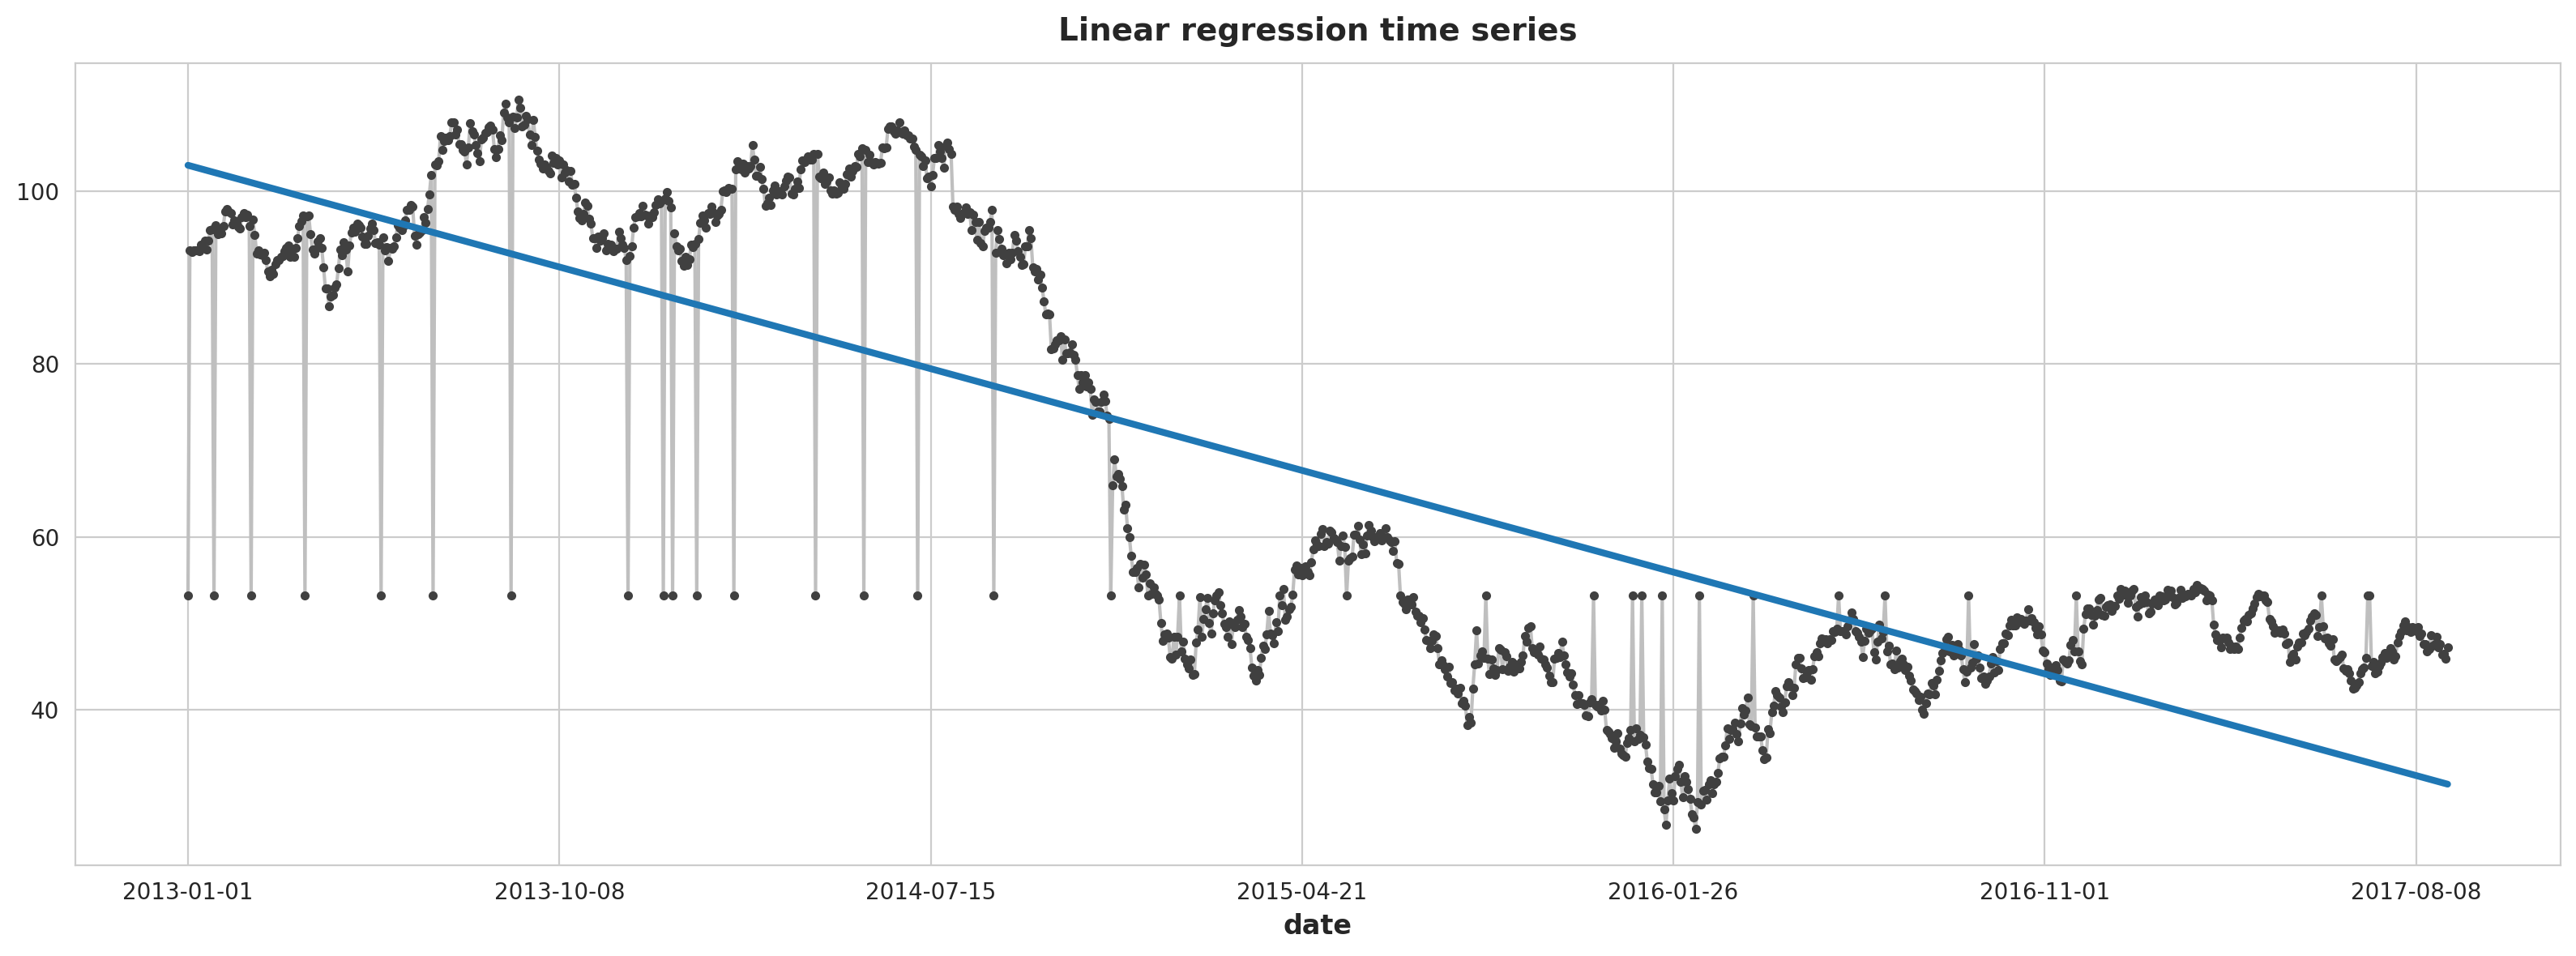

In [65]:
ax = y.plot(**plot_params)
ax = y_pred.plot(ax=ax, linewidth=3)
ax.set_title("Linear regression time series")

In [66]:
oil_copy['lag_1'] = oil_copy['dcoilwtico'].shift(1)
oil_copy.head()

,dcoilwtico,time,lag_1
date,,,
2013-01-01,53.19,0,NaN
2013-01-02,93.14,1,53.19
2013-01-03,92.97,2,93.14
2013-01-04,93.12,3,92.97
2013-01-07,93.20,4,93.12


In [67]:
oil_copy['lag_1'].fillna(oil_copy['lag_1'].mean(), inplace=True)
oil_copy.isnull().sum()

/tmp/ipykernel_4897/1773718234.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  oil_copy['lag_1'].fillna(oil_copy['lag_1'].mean(), inplace=True)


dcoilwtico    0
time          0
lag_1         0
dtype: int64

In [68]:
from sklearn.linear_model import LinearRegression

X = oil_copy.loc[:, ['lag_1']]
y = oil_copy.loc[:, 'dcoilwtico']  # create the target
y, X = y.align(X, join='inner')  # drop corresponding values in target

model = LinearRegression()
model.fit(X, y)

y_pred = pd.Series(model.predict(X), index=X.index)

Text(0.5, 1.0, 'lag plot of dcoilwtico')

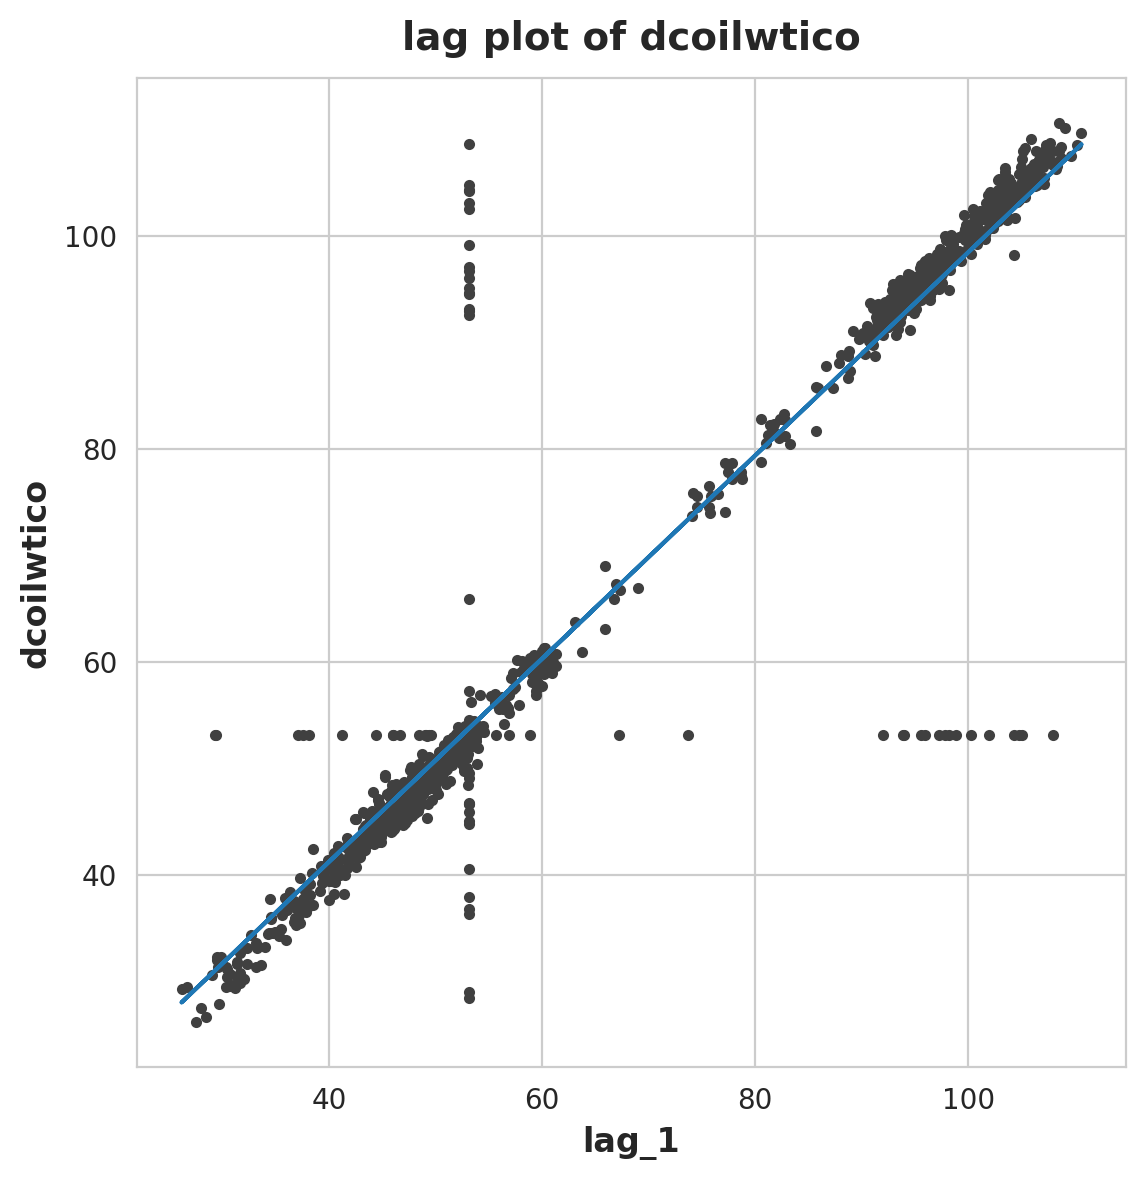

In [69]:
fig, ax = plt.subplots()
ax.plot(X['lag_1'], y, '.', color='0.25')
ax.plot(X['lag_1'], y_pred)
ax.set_aspect('equal')
ax.set_ylabel('dcoilwtico')
ax.set_xlabel('lag_1')
ax.set_title('lag plot of dcoilwtico')

The lag plot above shows how well we can plot a time plot for dcoilwtico

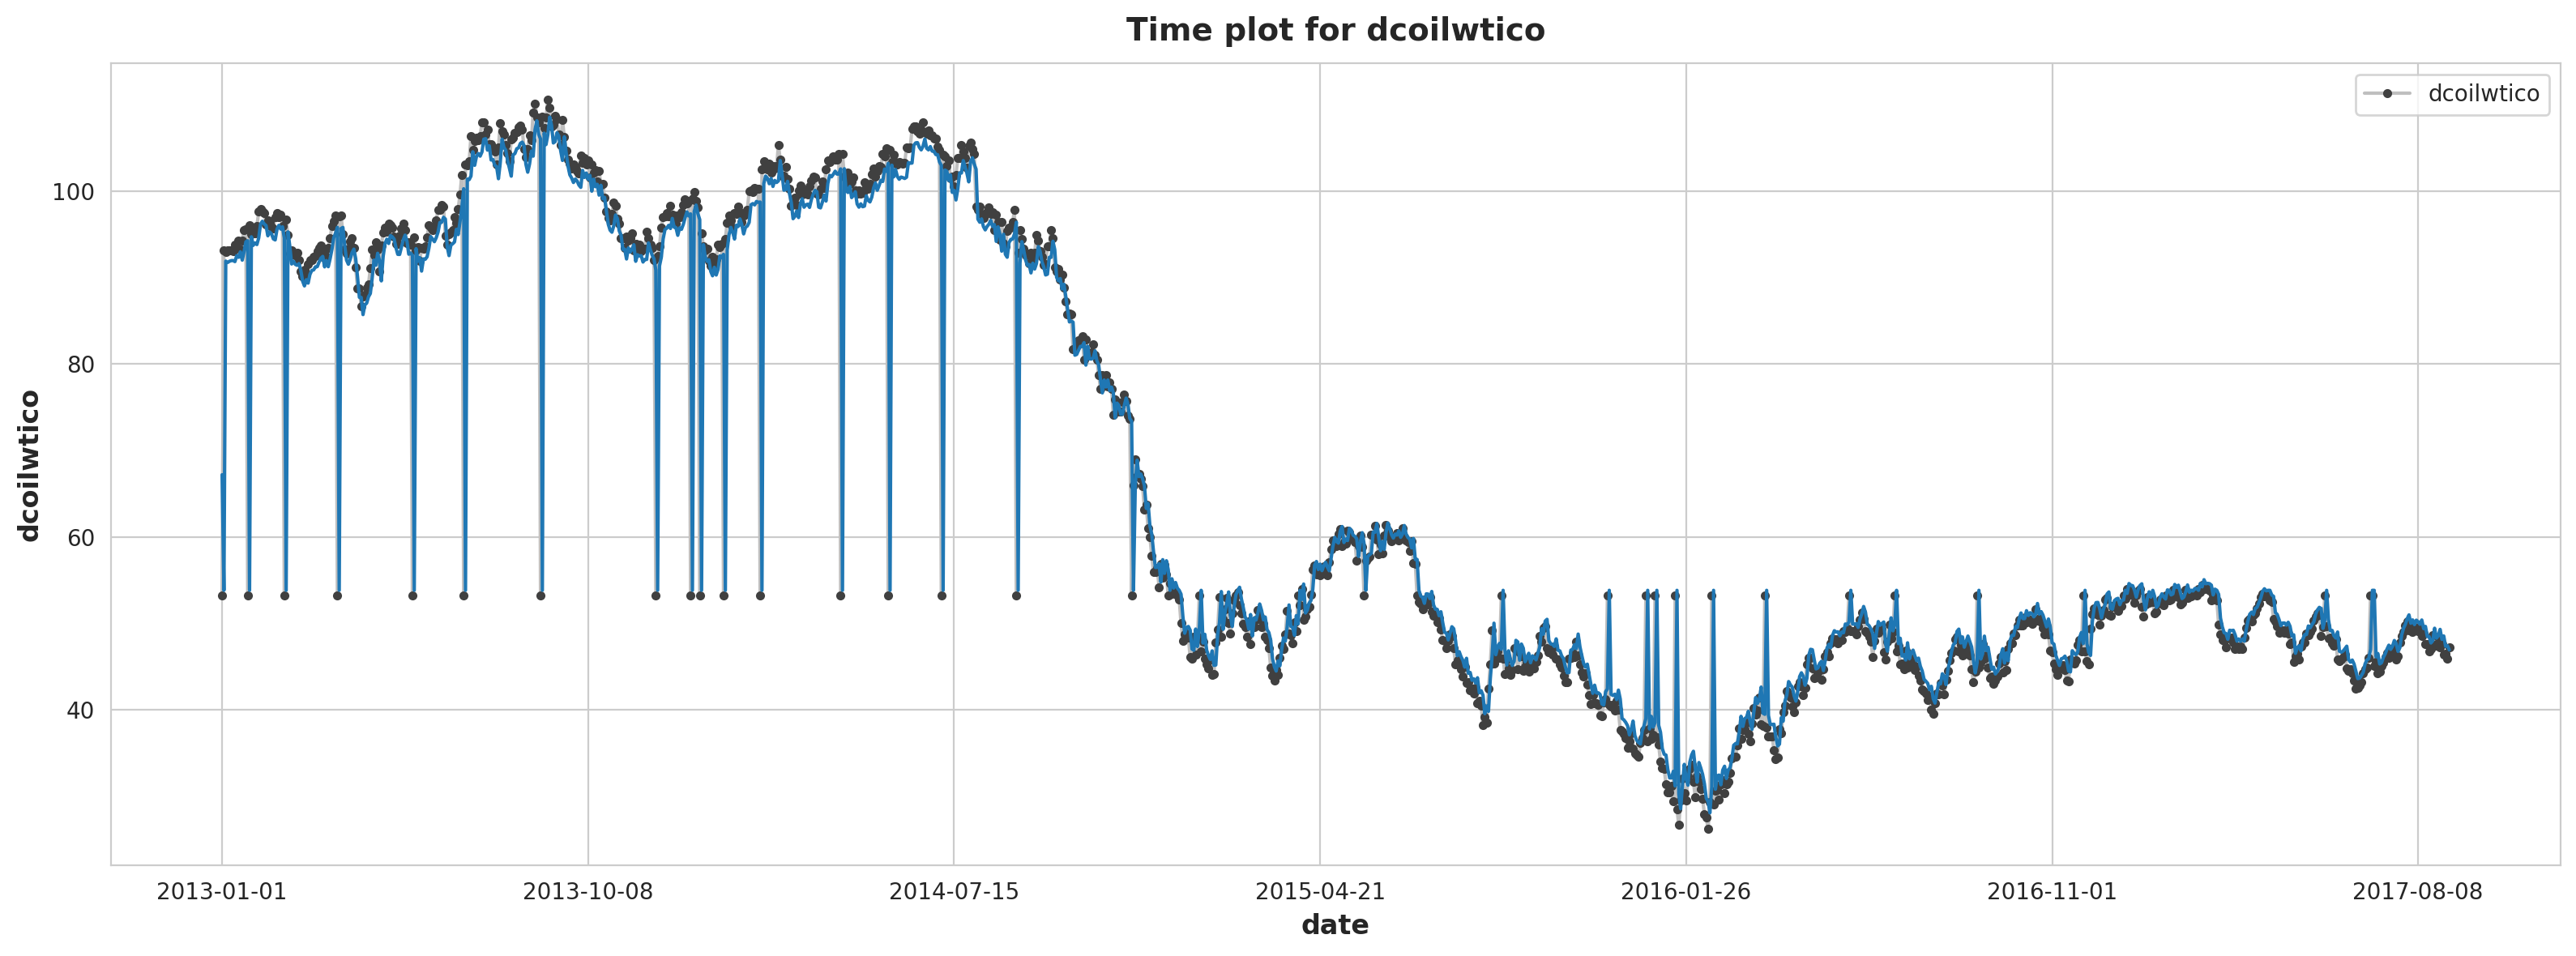

In [75]:
ax = y.plot(**plot_params)
ax = y_pred.plot()
ax.set_ylabel('dcoilwtico')
ax.set_title("Time plot for dcoilwtico")
plt.legend()